In [ ]:
%%capture
!pip install ultralytics

In [ ]:
from ultralytics import SAM
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from google.colab import drive
import matplotlib.patches as patches
import random
import pandas as pd
import time


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
annotations_df = pd.read_csv('/content/annotations.csv')
annotations_all = annotations_df.x, annotations_df.y, annotations_df.angle

In [ ]:
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

In [ ]:
#make sure all are same size
same_size_images=0
image_size = Image.open(annotations_df['image'][0]).size[0] #52.0 #216.0
bbox = [40, 40, image_size-40, image_size-40]
for img_name in annotations_df['image']:
      with Image.open(img_name) as img:
          if img.size==(image_size,image_size):
            same_size_images = same_size_images + 1
if same_size_images!=len(annotations_df):
  print(img_name)
  #stop

In [ ]:
# Prepare labels
max_values = np.array([image_size, image_size, 360.0]) # x, y, angle
annotations_all = np.zeros((same_size_images, 3))
for i in range(len(annotations_df)):
  annotations_all[i, :] = annotations_df.x[i], annotations_df.y[i], annotations_df.angle[i] % 360
y_tensor = torch.tensor(annotations_all, dtype = torch.float32)/max_values

/tmp/ipykernel_6799/3928096391.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_tensor = torch.tensor(annotations_all, dtype = torch.float32)/max_values


In [ ]:
# Prepare data (images & labels)
X_masks = []
X = []
base_sam = SAM('mobile_sam.pt')

for i in range(len(annotations_df)):
    img_path = annotations_df.image[i]

    start_time = time.time()
    results = base_sam(img_path, bboxes = [bbox], verbose = True)
    #print(f"Sam Operation {time.time() - start_time}")

    mask = results[0].masks.data[0].cpu().numpy()
    mask = np.array(Image.fromarray(mask))
    mask = np.expand_dims(np.uint8(mask),0)

    X = np.array(Image.open(img_path))
    X_masks.append(mask)

X_img_tensor = torch.tensor(np.array(X), dtype=torch.float32)
X_tensor = torch.tensor(np.array(X_masks), dtype=torch.float32)

print(f"X (Masks): {X_tensor.shape}")
print(f"y (Labels)): {y_tensor.shape}")



image 1/1 /content/192_65_108_108_mcroto6vz92f46dzox.jpg: 1024x1024 1 0, 1953.0ms
Speed: 91.1ms preprocess, 1953.0ms inference, 279.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /content/192_65_108_108_mcrotqwgtlr3dt7tfg.jpg: 1024x1024 1 0, 138.9ms
Speed: 15.9ms preprocess, 138.9ms inference, 1.4ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /content/192_65_108_108_mcrotsqn3wj8irs8p58.jpg: 1024x1024 1 0, 142.1ms
Speed: 8.3ms preprocess, 142.1ms inference, 5.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /content/192_65_108_108_mcrotu8x7rrapge5c2x.jpg: 1024x1024 1 0, 99.8ms
Speed: 16.5ms preprocess, 99.8ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /content/192_65_108_108_mcrotvrjk84cox3w6n.jpg: 1024x1024 1 0, 98.1ms
Speed: 7.2ms preprocess, 98.1ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /content/192_65_108_108_mcrotx9qc08z3l74sdt.jpg: 1024x1024 1 0, 143.2ms
Sp

## Show DB

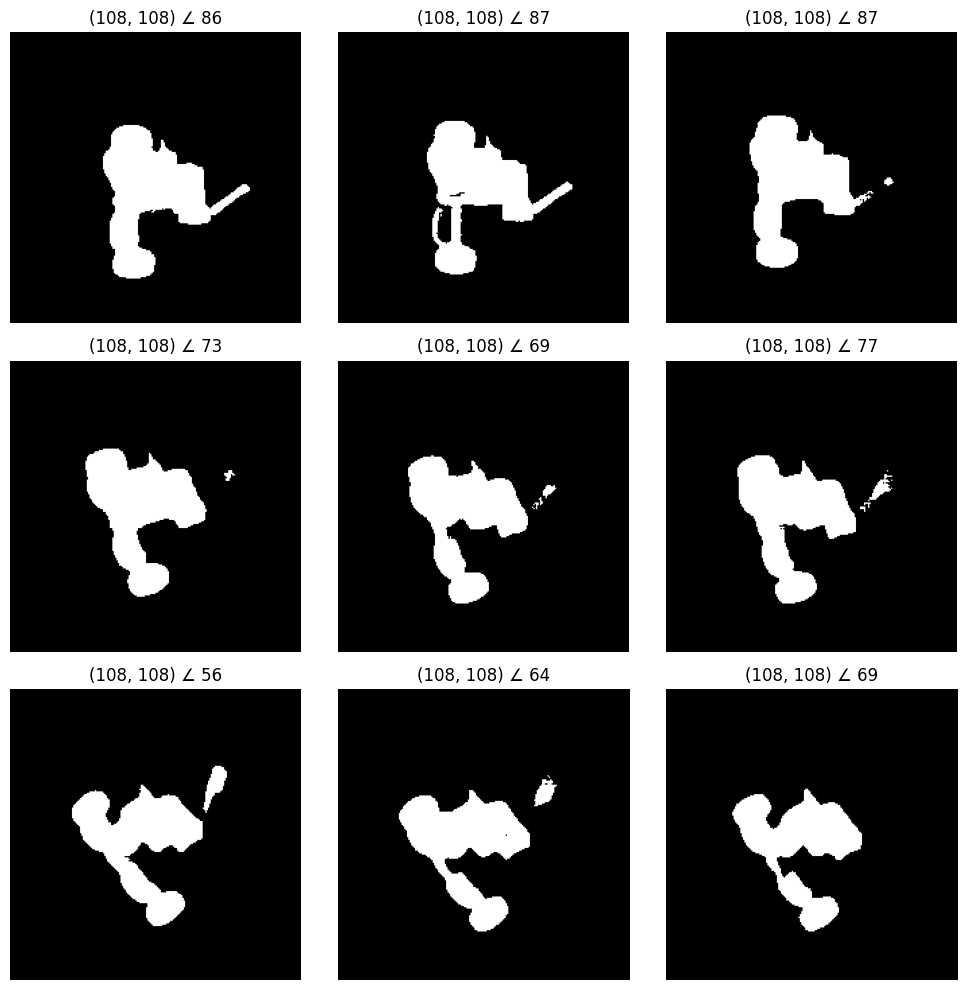

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

# Loop through the first 9 masks in X_tensor
for i in range(9):
    # Convert the tensor back to a numpy array for plotting
    mask_to_show = X_tensor[i][0].cpu().numpy()
    label = y_tensor[i].cpu().numpy()
    # Display the mask in grayscale
    axes[i].imshow(mask_to_show, cmap='gray')
    # {annotations_df.image[i]}
    axes[i].set_title(f"{int(label[0]*image_size), int(label[1]*image_size)} ∠ {int(label[2]*360)}")
    axes[i].axis('off') # Hide the axes for a cleaner look

plt.tight_layout()
plt.show()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class RobotPoseHead(nn.Module):
  def __init__(self):
    super(RobotPoseHead, self).__init__() # Mobile SAM encoder outputs a feature map o 256x64x64

    self.regressor = nn.Sequential(
        # nn.Conv2d(self.image_depth, 64, kernel_size=3, stride=1, padding=1),
        nn.Flatten(),
        nn.LazyLinear(128),
        nn.ReLU(),
        nn.Linear(128, 32),
        nn.ReLU(),
        nn.Linear(32, 3) # Final output: [x, y, angle]
    )

  def forward(self, x):
    return self.regressor(x)

    # Initialize the head
model_head = RobotPoseHead().to(device)
print("Regression head created")


Regression head created


## **Part #1** - Training

In [ ]:
# Configuration
optimizer = optim.Adam(model_head.parameters(), lr=0.0001)
mse_criterion = nn.MSELoss()
epochs = 120
batch_size = 16

# Lists to store loss history
history_pos_loss = []
history_angle_loss = []

model_head.train()

print(f"Starting training on {X_tensor.shape[0]} masks...")

for epoch in range(epochs):
    epoch_pos_loss = 0.0
    epoch_angle_loss = 0.0

    indices = torch.randperm(X_tensor.size(0))

    for i in range(0, len(indices), batch_size):
        batch_indices = indices[i : i + batch_size]

        # Ensure inputs and labels are Float32
        inputs = X_tensor[batch_indices].to(device).float()   # X_img_tensor
        labels = y_tensor[batch_indices].to(device).float()

        optimizer.zero_grad()

        # Forward pass
        predictions = model_head(inputs)

        # Split: [x, y, angle]
        pred_coords, true_coords = predictions[:, :2], labels[:, :2]
        pred_angle, true_angle = predictions[:, 2], labels[:, 2]

        # Position Loss
        loss_coords = mse_criterion(pred_coords, true_coords)

        # Angle Loss (Simple conversion to float to avoid Double error)
        angle_diff_rad = (2 * np.pi * (pred_angle - true_angle)).float()
        loss_angle = torch.mean(torch.atan2(torch.sin(angle_diff_rad), torch.cos(angle_diff_rad))**2)

        # Optimization
        total_loss = loss_coords + loss_angle
        total_loss.backward()
        optimizer.step()

        epoch_pos_loss += loss_coords.item()
        epoch_angle_loss += loss_angle.item()

    # Logging
    avg_pos = epoch_pos_loss / (len(X_tensor) / batch_size)
    avg_angle = epoch_angle_loss / (len(X_tensor) / batch_size)
    history_pos_loss.append(avg_pos)
    history_angle_loss.append(avg_angle)

    # Calculation for physical units
    pos_px = np.sqrt(avg_pos) * image_size
    angle_deg = np.sqrt(avg_angle) * (180 / np.pi)

    #print(f"Epoch [{epoch+1}/{epochs}] | Raw Pos Loss: {avg_pos:.6f} ({pos_px:.1f} px) | Raw Angle Loss: {avg_angle:.6f} ({angle_deg:.1f}°)")
    if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Pos Loss: {avg_pos:.6f} ({pos_px:.1f} px) | Angle Loss: {avg_angle:.6f} ({angle_deg:.1f}°)")

print("Training finished!")

Starting training on 77 masks...
Epoch [5/120] | Pos Loss: 0.037655 (41.9 px) | Angle Loss: 0.573339 (43.4°)
Epoch [10/120] | Pos Loss: 0.009514 (21.1 px) | Angle Loss: 0.069439 (15.1°)
Epoch [15/120] | Pos Loss: 0.005982 (16.7 px) | Angle Loss: 0.013365 (6.6°)
Epoch [20/120] | Pos Loss: 0.003686 (13.1 px) | Angle Loss: 0.003266 (3.3°)
Epoch [25/120] | Pos Loss: 0.002408 (10.6 px) | Angle Loss: 0.000944 (1.8°)
Epoch [30/120] | Pos Loss: 0.001642 (8.8 px) | Angle Loss: 0.000290 (1.0°)
Epoch [35/120] | Pos Loss: 0.001181 (7.4 px) | Angle Loss: 0.000072 (0.5°)
Epoch [40/120] | Pos Loss: 0.000879 (6.4 px) | Angle Loss: 0.000025 (0.3°)
Epoch [45/120] | Pos Loss: 0.000682 (5.6 px) | Angle Loss: 0.000009 (0.2°)
Epoch [50/120] | Pos Loss: 0.000577 (5.2 px) | Angle Loss: 0.000005 (0.1°)
Epoch [55/120] | Pos Loss: 0.000476 (4.7 px) | Angle Loss: 0.000002 (0.1°)
Epoch [60/120] | Pos Loss: 0.000400 (4.3 px) | Angle Loss: 0.000002 (0.1°)
Epoch [65/120] | Pos Loss: 0.000353 (4.1 px) | Angle Loss: 0.

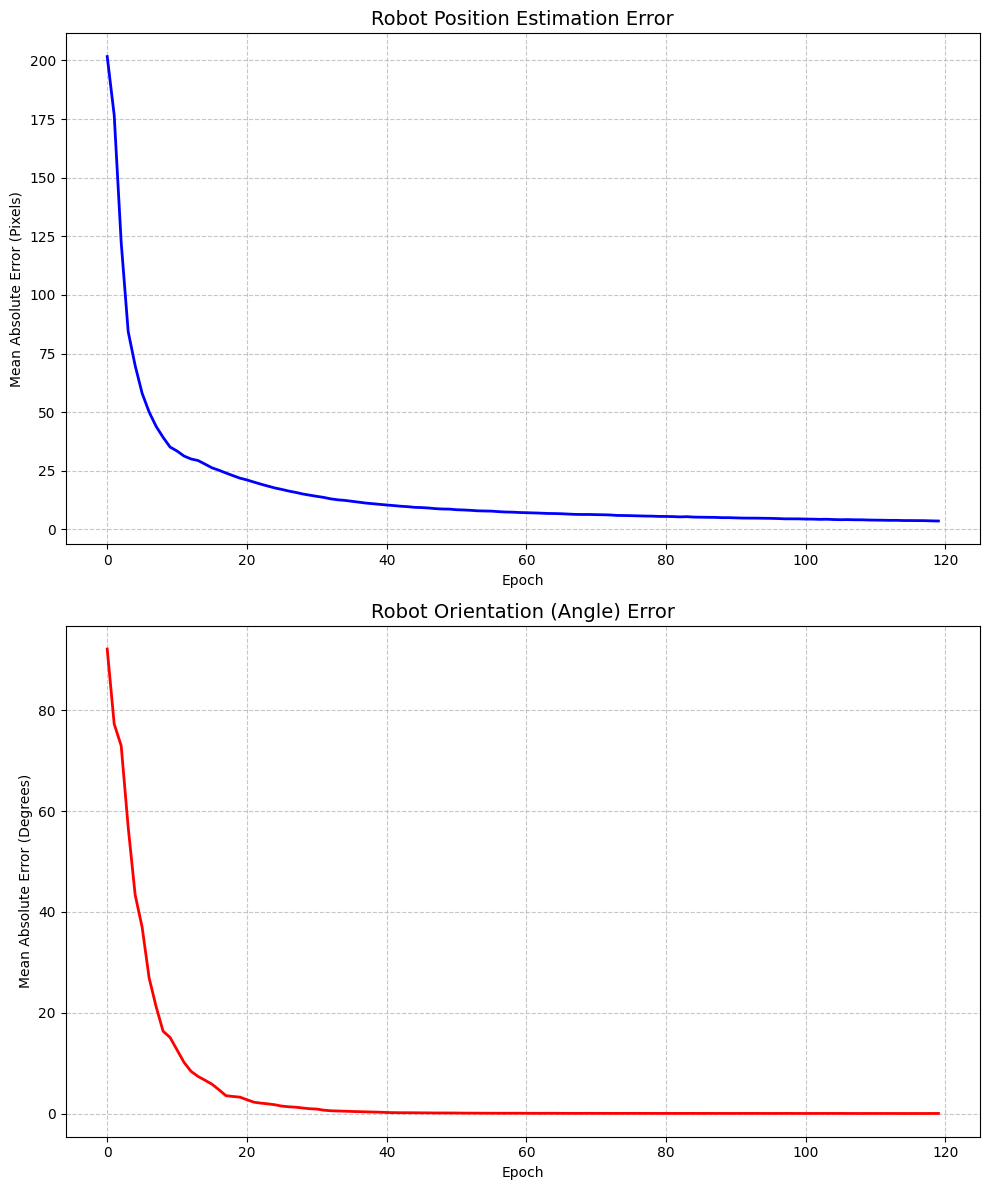

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# --- Plot 1: Position Error (in Pixels) ---
# convert Normalized MSE to Average Pixel Error using: sqrt(loss) * 360
pos_error_px = [np.sqrt(l) * 360 for l in history_pos_loss]

ax1.plot(pos_error_px, color='blue', lw=2)
ax1.set_title('Robot Position Estimation Error', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean Absolute Error (Pixels)')
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Angle Error (in Degrees) ---
# convert Normalized MSE to Average Degrees using: sqrt(loss) * (180/pi)
angle_error_deg = [np.sqrt(l) * (180 / np.pi) for l in history_angle_loss]

ax2.plot(angle_error_deg, color='red', lw=2)
ax2.set_title('Robot Orientation (Angle) Error', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error (Degrees)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()